In [3]:
#CREDIT CARD DEFAULT PREDICTION

#STEP 1: Import Libraries

# Basic Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model Selection
from sklearn.model_selection import train_test_split, GridSearchCV

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import warnings
warnings.filterwarnings("ignore")

#STEP 2: Load Dataset
url = "https://github.com/ybifoundation/Dataset/raw/main/Credit%20Default.csv"
df = pd.read_csv(url)
df.head()

#STEP 3: Basic Information
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Income          2000 non-null   float64
 1   Age             2000 non-null   float64
 2   Loan            2000 non-null   float64
 3   Loan to Income  2000 non-null   float64
 4   Default         2000 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 78.3 KB


,0
Income,0
Age,0
Loan,0
Loan to Income,0
Default,0


Index(['Income', 'Age', 'Loan', 'Loan to Income', 'Default'], dtype='object')


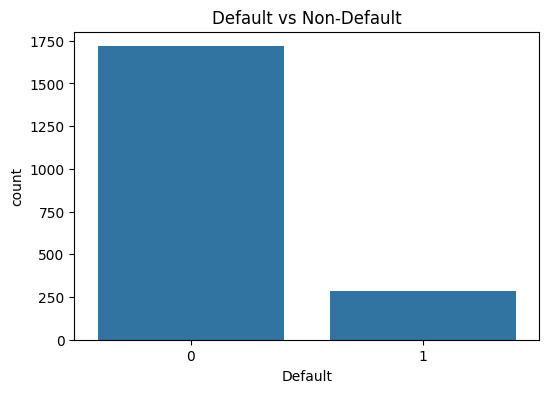

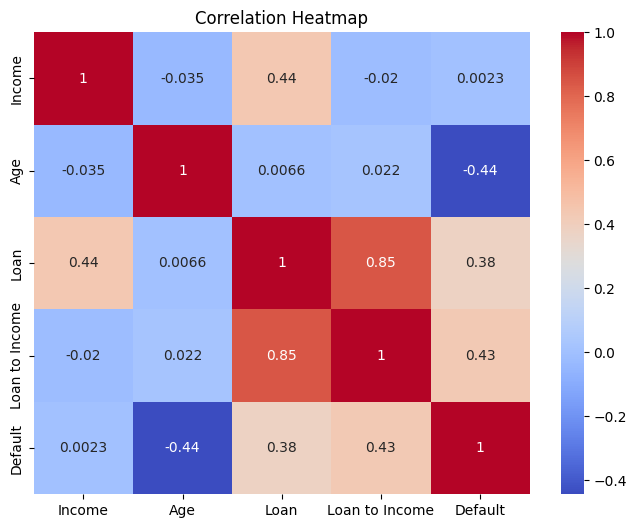

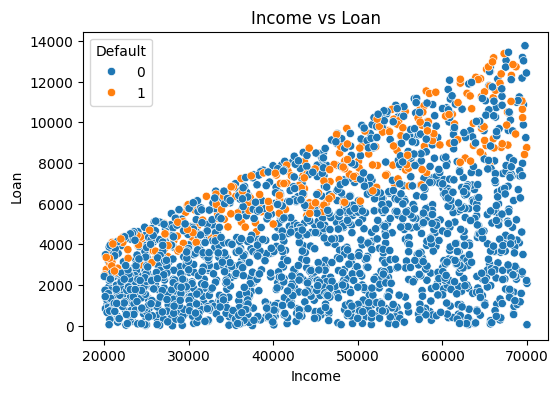

Accuracy: 0.955

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       343
           1       0.87      0.81      0.84        57

    accuracy                           0.95       400
   macro avg       0.92      0.89      0.91       400
weighted avg       0.95      0.95      0.95       400



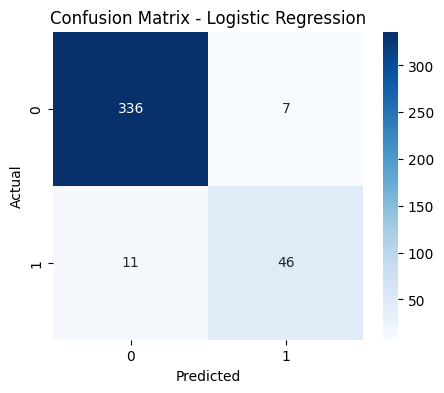

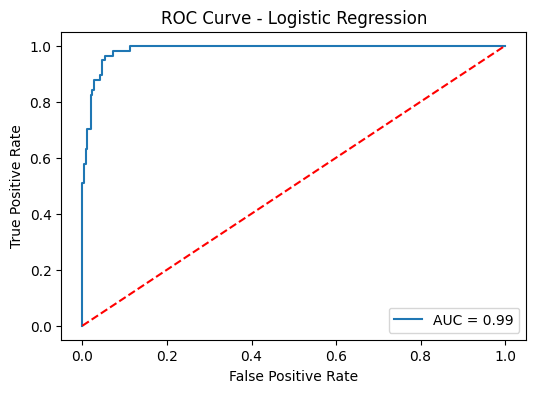

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       343
           1       1.00      1.00      1.00        57

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



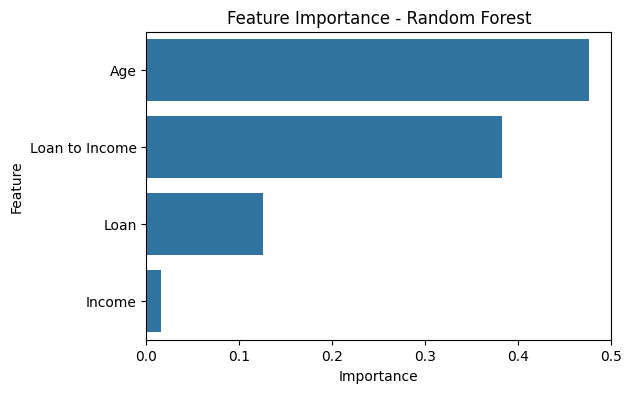

Best Parameters: {'max_depth': 5, 'n_estimators': 100}
Logistic Regression Accuracy: 0.955
Random Forest Accuracy: 1.0


In [2]:
#STEP 4: Data Cleaning

###Remove extra spaces in column names
df.columns = df.columns.str.strip()
print(df.columns)

###If Loan to Income is not present → create it
if 'Loan to Income' not in df.columns:
    df['Loan to Income'] = df['Loan'] / df['Income']

#STEP 5: Visualization

##Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Default', data=df)
plt.title("Default vs Non-Default")
plt.show()

##Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

##Income vs Loan (Colored by Default)
plt.figure(figsize=(6,4))
sns.scatterplot(x='Income', y='Loan', hue='Default', data=df)
plt.title("Income vs Loan")
plt.show()

# STEP 6: Define Features & Target
X = df.drop('Default', axis=1)
y = df['Default']

#STEP 7: Handle Missing Values
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

#STEP 8: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#STEP 9: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#MODEL 1: Logistic Regression (Baseline Model)
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

##Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

##Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

##ROC Curve
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

#MODEL 2: Random Forest (Advanced Model)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

## Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

##Feature Importance
importances = rf.feature_importances_
feature_names = df.drop('Default', axis=1).columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importance - Random Forest")
plt.show()

#Hyperparameter Tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=5)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

#Final Comparison
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))
